In [5]:
# ---------------------------
# IMPORTS
# ---------------------------
import pandas as pd
from pybaseball import statcast
from pybaseball import cache

# Set new cache location
cache.config.cache_dir = r"E:\Baseball\pybaseball_cache"
# Enable caching so you only download each month once
cache.enable()


# ---------------------------
# FUNCTION: Pull one month of Statcast data
# ---------------------------
def get_month(year: int, month: int) -> pd.DataFrame:
    """
    Downloads all MLB pitches for a specific month of a given year.
    Example: get_month(2023, 4) → All pitches in April 2023
    """

    # Month start and end days
    month_starts = {
        1:  "01", 2:  "01", 3:  "01", 4:  "01",
        5:  "01", 6:  "01", 7:  "01", 8:  "01",
        9:  "01", 10: "01", 11: "01", 12: "01"
    }

    month_ends = {
        1:  "31", 2:  "28", 3:  "31", 4:  "30",
        5:  "31", 6:  "30", 7:  "31", 8:  "31",
        9:  "30", 10: "31", 11: "30", 12: "31"
    }

    # Automatically adjust leap year February
    if month == 2 and year % 4 == 0:
        month_ends[2] = "29"

    start_date = f"{year}-{month:02d}-{month_starts[month]}"
    end_date   = f"{year}-{month:02d}-{month_ends[month]}"

    print(f"📥 Pulling Statcast data: {start_date} → {end_date}")

    df = statcast(start_dt=start_date, end_dt=end_date)

    print(f"✔ Completed month {month} ({len(df)} pitches)\n")
    return df


# ---------------------------
# FUNCTION: Pull an entire MLB season month-by-month
# ---------------------------
def get_season_by_month(year: int) -> pd.DataFrame:
    """
    Downloads ALL MLB pitches for a full season,
    month-by-month to avoid Statcast errors.
    """
    dfs = []

    for month in range(1, 13):
        try:
            df_month = get_month(year, month)
            if df_month is not None and len(df_month) > 0:
                dfs.append(df_month)
        except Exception as e:
            print(f"⚠️ Error pulling month {month}: {e}")

    df_all = pd.concat(dfs, ignore_index=True)
    print(f"🎉 Finished season {year}! Total pitches: {len(df_all)}")

    return df_all


In [6]:
df_2023 = get_season_by_month(2023)

📥 Pulling Statcast data: 2023-01-01 → 2023-01-31
This is a large query, it may take a moment to complete
Skipping offseason dates


0it [00:00, ?it/s]

✔ Completed month 1 (0 pitches)

📥 Pulling Statcast data: 2023-02-01 → 2023-02-28
This is a large query, it may take a moment to complete


Skipping offseason dates


0it [00:00, ?it/s]

...

✔ Completed month 11 (273 pitches)

📥 Pulling Statcast data: 2023-12-01 → 2023-12-31
This is a large query, it may take a moment to complete



E:\Anaconda\Lib\site-packages\pybaseball\statcast.py:85: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  final_data = pd.concat(dataframe_list, axis=0).convert_dtypes(convert_string=False)


Skipping offseason dates


0it [00:00, ?it/s]


✔ Completed month 12 (0 pitches)

🎉 Finished season 2023! Total pitches: 774038


In [7]:
df_2023.head()

,pitch_type,game_date,release_speed,release_pos_x,release_pos_z,player_name,batter,pitcher,events,description,...,batter_days_until_next_game,api_break_z_with_gravity,api_break_x_arm,api_break_x_batter_in,arm_angle,attack_angle,attack_direction,swing_path_tilt,intercept_ball_minus_batter_pos_x_inches,intercept_ball_minus_batter_pos_y_inches
0,ST,2023-03-31,84.5,3.41,5.29,"Puk, A.J.",643446,640462,field_out,hit_into_play,...,1,2.65,-0.97,-0.97,25.9,<NA>,<NA>,<NA>,<NA>,<NA>
1,ST,2023-03-31,84.1,3.4,5.38,"Puk, A.J.",643446,640462,None,foul,...,1,2.85,-1.38,-1.38,27.4,<NA>,<NA>,<NA>,<NA>,<NA>
2,ST,2023-03-31,83.7,3.39,5.32,"Puk, A.J.",643446,640462,None,foul,...,1,2.78,-1.35,-1.35,26.2,<NA>,<NA>,<NA>,<NA>,<NA>
3,FF,2023-03-31,96.3,3.3,5.46,"Puk, A.J.",592192,640462,strikeout,swinging_strike,...,1,1.1,0.88,-0.88,30.7,<NA>,<NA>,<NA>,<NA>,<NA>
4,ST,2023-03-31,84.0,3.4,5.38,"Puk, A.J.",592192,640462,None,swinging_strike,...,1,2.75,-1.09,1.09,29.5,<NA>,<NA>,<NA>,<NA>,<NA>


In [8]:
df_2023.columns

Index(['pitch_type', 'game_date', 'release_speed', 'release_pos_x',
       'release_pos_z', 'player_name', 'batter', 'pitcher', 'events',
       'description',
       ...
       'batter_days_until_next_game', 'api_break_z_with_gravity',
       'api_break_x_arm', 'api_break_x_batter_in', 'arm_angle', 'attack_angle',
       'attack_direction', 'swing_path_tilt',
       'intercept_ball_minus_batter_pos_x_inches',
       'intercept_ball_minus_batter_pos_y_inches'],
      dtype='object', length=118)

In [9]:
for col in df_2023.columns:
    print(col)


pitch_type
game_date
release_speed
release_pos_x
release_pos_z
player_name
batter
pitcher
events
description
spin_dir
spin_rate_deprecated
break_angle_deprecated
break_length_deprecated
zone
des
game_type
stand
p_throws
home_team
away_team
type
hit_location
bb_type
balls
strikes
game_year
pfx_x
pfx_z
plate_x
plate_z
on_3b
on_2b
on_1b
outs_when_up
inning
inning_topbot
hc_x
hc_y
tfs_deprecated
tfs_zulu_deprecated
umpire
sv_id
vx0
vy0
vz0
ax
ay
az
sz_top
sz_bot
hit_distance_sc
launch_speed
launch_angle
effective_speed
release_spin_rate
release_extension
game_pk
fielder_2
fielder_3
fielder_4
fielder_5
fielder_6
fielder_7
fielder_8
fielder_9
release_pos_y
estimated_ba_using_speedangle
estimated_woba_using_speedangle
woba_value
woba_denom
babip_value
iso_value
launch_speed_angle
at_bat_number
pitch_number
pitch_name
home_score
away_score
bat_score
fld_score
post_away_score
post_home_score
post_bat_score
post_fld_score
if_fielding_alignment
of_fielding_alignment
spin_axis
delta_home_win_exp
d

In [10]:
import pandas as pd
import numpy as np

# ----------------------------
# 1. Filter Gerrit Cole
# ----------------------------
cole = df_2023[df_2023["pitcher"] == 543037].copy()
cole = cole.reset_index(drop=True)

# ----------------------------
# 2. Tunneling function (in INCHES)
# ----------------------------
def tunneling_metrics_inches(df):
    df = df.copy()

    # Release differential (inches)
    #essentially average variance of the pitches thrown
    df['release_diff'] = 12 * np.sqrt(
        (df['release_pos_x'].diff())**2 +
        (df['release_pos_z'].diff())**2 +
        (df['release_pos_y'].diff())**2
    )

    # Tunnel point at 23.8 ft from plate
    #How far apart two pitch types are at the tunnel point — usually around 23–24 feet from home plate (roughly halfway to the hitter).
    release_y = df['release_pos_y']
    vx0, vy0, vz0 = df['vx0'], df['vy0'], df['vz0']

    # Tunnel point coordinates (still in feet)
    df['tunnel_x'] = df['release_pos_x'] + vx0 * ((release_y - 23.8) / -vy0)
    df['tunnel_z'] = df['release_pos_z'] + vz0 * ((release_y - 23.8) / -vy0)

    # Tunnel diff (inches)
    df['tunnel_diff'] = 12 * np.sqrt(
        (df['tunnel_x'].diff())**2 +
        (df['tunnel_z'].diff())**2
    )

    # Plate diff (inches)
    df['plate_diff'] = 12 * np.sqrt(
        (df['plate_x'].diff())**2 +
        (df['plate_z'].diff())**2
    )

    # Ratio stays the same (unitless)
    df['tunnel_ratio'] = df['tunnel_diff'] / df['plate_diff']

    return df

# ----------------------------
# 3. Apply tunneling model
# ----------------------------
cole_inches = tunneling_metrics_inches(cole)

# ----------------------------
# 4. Summary in inches
# ----------------------------
summary_inches = cole_inches.groupby('pitch_name')[['release_diff',
                                                    'tunnel_diff',
                                                    'plate_diff',
                                                    'tunnel_ratio']].mean().round(2)
print(summary_inches)


                 release_diff  tunnel_diff  plate_diff  tunnel_ratio
pitch_name                                                          
4-Seam Fastball          2.87         9.97       17.39          0.77
Changeup                  3.7        11.13       19.93          0.73
Cutter                   3.01          9.6       16.82          0.78
Knuckle Curve            3.63        15.47       18.14          1.52
Sinker                   3.68         8.83       13.48          0.65
Slider                   3.28        10.27       19.43          0.77


# Metrics Explained
**release_diff**: The average release-point variation for pitches thrown of the same type.

**tunnel_diff**: How far apart two pitch types are at the tunnel point — usually around 23–24 feet from home plate (roughly halfway to the hitter).

**plate_diff**: How far apart two pitch types end up when they cross home plate.

**tunnel_ratio**: 
How well the pitcher keeps two pitches together early relative to how far apart they get late.

Interpretation (super important):

Low ratio (0.2–0.6) → excellent tunneling:
→ Pitches look the same early but end far apart (most deception).

Around 1.0 → mediocre tunneling:
→ Early and late separation are similar.

1.0 → bad tunneling:
→ Pitches separate early before they ever reach the plate.

In [11]:
import numpy as np
import pandas as pd

def compute_true_tunneling(
    df,
    pitcher_name,
    pitch1,
    pitch2,
    tunnel_time=0.150,
    max_release_diff_in=3.0,   # max allowed release distance (inches)
    max_dir_diff_deg=5.0       # max allowed direction angle difference (degrees)
):
    """
    Compute TRUE tunneling between pitch1 -> pitch2 for a given pitcher,
    enforcing similar release point AND similar initial trajectory.

    Returns rows where:
      - current pitch_type == pitch1
      - next   pitch_type == pitch2
      - release points are within max_release_diff_in
      - initial launch directions are within max_dir_diff_deg

    Distances are in INCHES, ratios are unitless.
    """

    # 1) Filter to this pitcher
    data = df[df['player_name'] == pitcher_name].copy()

    needed_cols = [
        'pitch_type',
        'release_pos_x','release_pos_y','release_pos_z',
        'vx0','vy0','vz0','ax','ay','az',
        'plate_x','plate_z',
        'game_pk','at_bat_number','pitch_number'
    ]
    data = data[needed_cols].copy()

    # 2) Sort in real pitch order
    data = data.sort_values(['game_pk','at_bat_number','pitch_number'])

    # 3) Compute tunnel position at tunnel_time seconds after release
    t = tunnel_time

    data['tunnel_x'] = data['release_pos_x'] + data['vx0']*t + 0.5*data['ax']*(t**2)
    data['tunnel_y'] = data['release_pos_y'] + data['vy0']*t + 0.5*data['ay']*(t**2)
    data['tunnel_z'] = data['release_pos_z'] + data['vz0']*t + 0.5*data['az']*(t**2)

    # 4) Compute initial direction unit vector for each pitch
    speed0 = np.sqrt(data['vx0']**2 + data['vy0']**2 + data['vz0']**2)
    # Avoid divide-by-zero
    speed0 = speed0.replace(0, np.nan)

    data['dir_x'] = data['vx0'] / speed0
    data['dir_y'] = data['vy0'] / speed0
    data['dir_z'] = data['vz0'] / speed0

    # 5) Shift to make next-pitch columns
    for col in ['pitch_type','release_pos_x','release_pos_y','release_pos_z',
                'tunnel_x','tunnel_y','tunnel_z',
                'plate_x','plate_z',
                'dir_x','dir_y','dir_z']:
        data[f'next_{col}'] = data[col].shift(-1)

    # 6) Only pitch1 -> pitch2 sequences
    pairs = data[
        (data['pitch_type'] == pitch1) &
        (data['next_pitch_type'] == pitch2)
    ].copy()

    if pairs.empty:
        print(f"No {pitch1} → {pitch2} sequences found for {pitcher_name}")
        return pairs

    # 7) Ensure numeric types
    numeric_cols = [
        'release_pos_x','release_pos_y','release_pos_z',
        'next_release_pos_x','next_release_pos_y','next_release_pos_z',
        'tunnel_x','tunnel_y','tunnel_z',
        'next_tunnel_x','next_tunnel_y','next_tunnel_z',
        'plate_x','plate_z','next_plate_x','next_plate_z',
        'dir_x','dir_y','dir_z',
        'next_dir_x','next_dir_y','next_dir_z'
    ]
    for col in numeric_cols:
        pairs[col] = pd.to_numeric(pairs[col], errors='coerce')

    pairs = pairs.dropna(subset=numeric_cols)

    # 8) Release distance in FEET, convert to INCHES
    release_diff_ft = np.sqrt(
        (pairs['release_pos_x'] - pairs['next_release_pos_x'])**2 +
        (pairs['release_pos_y'] - pairs['next_release_pos_y'])**2 +
        (pairs['release_pos_z'] - pairs['next_release_pos_z'])**2
    )
    pairs['release_diff_in'] = release_diff_ft * 12.0

    # 9) Initial direction angle difference (degrees)
    dot = (
        pairs['dir_x'] * pairs['next_dir_x'] +
        pairs['dir_y'] * pairs['next_dir_y'] +
        pairs['dir_z'] * pairs['next_dir_z']
    )
    # clamp for numerical safety
    dot = dot.clip(-1.0, 1.0)

    pairs['dir_diff_deg'] = np.degrees(np.arccos(dot))

    # 10) Keep ONLY pairs that share same tunnel line (within thresholds)
    true_pairs = pairs[
        (pairs['release_diff_in'] <= max_release_diff_in) &
        (pairs['dir_diff_deg']   <= max_dir_diff_deg)
    ].copy()

    if true_pairs.empty:
        print(
            f"No {pitch1} → {pitch2} pairs for {pitcher_name} "
            f"within {max_release_diff_in} in release & {max_dir_diff_deg}° direction."
        )
        return true_pairs

    # 11) Compute tunnel + plate separation (FEET → INCHES)
    tunnel_diff_ft = np.sqrt(
        (true_pairs['tunnel_x'] - true_pairs['next_tunnel_x'])**2 +
        (true_pairs['tunnel_y'] - true_pairs['next_tunnel_y'])**2 +
        (true_pairs['tunnel_z'] - true_pairs['next_tunnel_z'])**2
    )
    plate_diff_ft = np.sqrt(
        (true_pairs['plate_x'] - true_pairs['next_plate_x'])**2 +
        (true_pairs['plate_z'] - true_pairs['next_plate_z'])**2
    )

    true_pairs['tunnel_diff_in'] = tunnel_diff_ft * 12.0
    true_pairs['plate_diff_in']  = plate_diff_ft * 12.0

    # 12) Tunneling ratio (unitless)
    true_pairs['tunnel_ratio'] = true_pairs['tunnel_diff_in'] / true_pairs['plate_diff_in']

    return true_pairs


# Gerrit Cole FB SL Tunnel
Set max release difference to 3 inches and max direction difference to 5 degrees to get pitches coming out of a very similar tunnel, and found the difference at the tunnel point (150ms) was around 20 inches which is relatively large

In [12]:
cole_true_ff_sl = compute_true_tunneling(
    df_2023,
    pitcher_name="Cole, Gerrit",
    pitch1="FF",
    pitch2="SL",
    tunnel_time=0.150,      # 150 ms decision point
    max_release_diff_in=3.0,  # same release within 3 inches
    max_dir_diff_deg=5.0      # same initial direction within 5 degrees
)

summary = cole_true_ff_sl[['release_diff_in',
                           'dir_diff_deg',
                           'tunnel_diff_in',
                           'plate_diff_in',
                           'tunnel_ratio']].describe().loc[['count','mean']]

display(summary.round(3))



,release_diff_in,dir_diff_deg,tunnel_diff_in,plate_diff_in,tunnel_ratio
count,175.0,175.0,175.0,175.0,175.0
mean,1.959,1.396,20.134,21.799,1.396


# Taking Y axis away when tunneling
y-axis refers to the distance from pitcher to home plate, which isn't perceieved by hitters, so only using the x and z axis allowed for a much smaller tunnel difference (20 in compared to 6 in)

In [13]:
import numpy as np
import pandas as pd

def compute_true_tunneling(
    df,
    pitcher_name,
    pitch1,
    pitch2,
    tunnel_time=0.150,
    max_release_diff_in=3.0,   # max allowed release distance (inches)
    max_dir_diff_deg=5.0       # max allowed direction angle difference (degrees)
):
    """
    Compute TRUE tunneling between pitch1 -> pitch2 for a given pitcher,
    enforcing similar release point AND similar initial trajectory.

    Returns rows where:
      - current pitch_type == pitch1
      - next   pitch_type == pitch2
      - release points are within max_release_diff_in
      - initial launch directions are within max_dir_diff_deg

    Distances are in INCHES, ratios are unitless.
    """

    # 1) Filter to this pitcher
    data = df[df['player_name'] == pitcher_name].copy()

    needed_cols = [
        'pitch_type',
        'release_pos_x','release_pos_y','release_pos_z',
        'vx0','vy0','vz0','ax','ay','az',
        'plate_x','plate_z',
        'game_pk','at_bat_number','pitch_number'
    ]
    data = data[needed_cols].copy()

    # 2) Sort in real pitch order
    data = data.sort_values(['game_pk','at_bat_number','pitch_number'])

    # 3) Compute tunnel position at tunnel_time seconds after release
    t = tunnel_time

    data['tunnel_x'] = data['release_pos_x'] + data['vx0']*t + 0.5*data['ax']*(t**2)
    data['tunnel_y'] = data['release_pos_y'] + data['vy0']*t + 0.5*data['ay']*(t**2)
    data['tunnel_z'] = data['release_pos_z'] + data['vz0']*t + 0.5*data['az']*(t**2)

    # 4) Compute initial direction unit vector for each pitch
    speed0 = np.sqrt(data['vx0']**2 + data['vy0']**2 + data['vz0']**2)
    # Avoid divide-by-zero
    speed0 = speed0.replace(0, np.nan)

    data['dir_x'] = data['vx0'] / speed0
    data['dir_y'] = data['vy0'] / speed0
    data['dir_z'] = data['vz0'] / speed0

    # 5) Shift to make next-pitch columns
    for col in ['pitch_type','release_pos_x','release_pos_y','release_pos_z',
                'tunnel_x','tunnel_y','tunnel_z',
                'plate_x','plate_z',
                'dir_x','dir_y','dir_z']:
        data[f'next_{col}'] = data[col].shift(-1)

    # 6) Only pitch1 -> pitch2 sequences
    pairs = data[
        (data['pitch_type'] == pitch1) &
        (data['next_pitch_type'] == pitch2)
    ].copy()

    if pairs.empty:
        print(f"No {pitch1} → {pitch2} sequences found for {pitcher_name}")
        return pairs

    # 7) Ensure numeric types
    numeric_cols = [
        'release_pos_x','release_pos_y','release_pos_z',
        'next_release_pos_x','next_release_pos_y','next_release_pos_z',
        'tunnel_x','tunnel_y','tunnel_z',
        'next_tunnel_x','next_tunnel_y','next_tunnel_z',
        'plate_x','plate_z','next_plate_x','next_plate_z',
        'dir_x','dir_y','dir_z',
        'next_dir_x','next_dir_y','next_dir_z'
    ]
    for col in numeric_cols:
        pairs[col] = pd.to_numeric(pairs[col], errors='coerce')

    pairs = pairs.dropna(subset=numeric_cols)

    # 8) Release distance in FEET, convert to INCHES
    release_diff_ft = np.sqrt(
        (pairs['release_pos_x'] - pairs['next_release_pos_x'])**2 +
        (pairs['release_pos_y'] - pairs['next_release_pos_y'])**2 +
        (pairs['release_pos_z'] - pairs['next_release_pos_z'])**2
    )
    pairs['release_diff_in'] = release_diff_ft * 12.0

    # 9) Initial direction angle difference (degrees)
    dot = (
        pairs['dir_x'] * pairs['next_dir_x'] +
        pairs['dir_y'] * pairs['next_dir_y'] +
        pairs['dir_z'] * pairs['next_dir_z']
    )
    # clamp for numerical safety
    dot = dot.clip(-1.0, 1.0)

    pairs['dir_diff_deg'] = np.degrees(np.arccos(dot))

    # 10) Keep ONLY pairs that share same tunnel line (within thresholds)
    true_pairs = pairs[
        (pairs['release_diff_in'] <= max_release_diff_in) &
        (pairs['dir_diff_deg']   <= max_dir_diff_deg)
    ].copy()

    if true_pairs.empty:
        print(
            f"No {pitch1} → {pitch2} pairs for {pitcher_name} "
            f"within {max_release_diff_in} in release & {max_dir_diff_deg}° direction."
        )
        return true_pairs

    # 11) Compute tunnel separation in FEET

    # 11a) Full 3D distance (x, y, z)
    tunnel_diff_3d_ft = np.sqrt(
        (true_pairs['tunnel_x'] - true_pairs['next_tunnel_x'])**2 +
        (true_pairs['tunnel_y'] - true_pairs['next_tunnel_y'])**2 +
        (true_pairs['tunnel_z'] - true_pairs['next_tunnel_z'])**2
    )

    # 11b) Visual-only x/z distance
    tunnel_diff_xz_ft = np.sqrt(
        (true_pairs['tunnel_x'] - true_pairs['next_tunnel_x'])**2 +
        (true_pairs['tunnel_z'] - true_pairs['next_tunnel_z'])**2
    )

    # 11c) Individual axis components (in feet)
    tunnel_diff_x_ft = (true_pairs['tunnel_x'] - true_pairs['next_tunnel_x']).abs()
    tunnel_diff_z_ft = (true_pairs['tunnel_z'] - true_pairs['next_tunnel_z']).abs()

    # 11d) Plate separation (already x,z only)
    plate_diff_x_ft = (true_pairs['plate_x'] - true_pairs['next_plate_x']).abs()
    plate_diff_z_ft = (true_pairs['plate_z'] - true_pairs['next_plate_z']).abs()

    plate_diff_ft = np.sqrt(
        (true_pairs['plate_x'] - true_pairs['next_plate_x'])**2 +
        (true_pairs['plate_z'] - true_pairs['next_plate_z'])**2
    )


    # 12) Convert all to INCHES
    true_pairs['tunnel_diff_3d_in'] = tunnel_diff_3d_ft * 12.0
    true_pairs['tunnel_diff_xz_in'] = tunnel_diff_xz_ft * 12.0
    true_pairs['tunnel_diff_x_in']  = tunnel_diff_x_ft  * 12.0
    true_pairs['tunnel_diff_z_in']  = tunnel_diff_z_ft  * 12.0

    true_pairs['plate_diff_xz_in']     = plate_diff_ft     * 12.0
    true_pairs['plate_diff_x_in']   = plate_diff_x_ft   * 12.0
    true_pairs['plate_diff_z_in']   = plate_diff_z_ft   * 12.0
    true_pairs['plate_diff_in'] = plate_diff_ft * 12.0



    # 13) Tunneling ratios (unitless)
    true_pairs['tunnel_ratio_3d'] = true_pairs['tunnel_diff_3d_in'] / true_pairs['plate_diff_in']
    true_pairs['tunnel_ratio_xz'] = true_pairs['tunnel_diff_xz_in'] / true_pairs['plate_diff_in']
    true_pairs['tunnel_ratio_x']  = true_pairs['tunnel_diff_x_in']  / true_pairs['plate_diff_in']
    true_pairs['tunnel_ratio_z']  = true_pairs['tunnel_diff_z_in']  / true_pairs['plate_diff_in']

    return true_pairs


xz diff is bigger because Pythagorean theorem

In [14]:
cole = compute_true_tunneling(df_2023,"Cole, Gerrit","FF","SL")

cole[['tunnel_diff_x_in',
      'tunnel_diff_z_in',
      'tunnel_diff_xz_in',
      'tunnel_diff_3d_in']].describe().loc[['count','mean']]



,tunnel_diff_x_in,tunnel_diff_z_in,tunnel_diff_xz_in,tunnel_diff_3d_in
count,175.0,175.0,175.0,175.0
mean,3.602934,4.383594,6.185717,20.133562


# Tunnel Leaderboard for FB SL combos

In [15]:
pitchers = df_2023['player_name'].unique()

In [16]:
results = []

for name in pitchers:
    try:
        pairs = compute_true_tunneling(
            df_2023,
            pitcher_name=name,
            pitch1="FF",
            pitch2="SL",
            tunnel_time=0.150,
            max_release_diff_in=3.0,
            max_dir_diff_deg=5.0
        )

        # Skip if no valid pairs
        if pairs is None or len(pairs) < 5:
            continue

        results.append({
            'pitcher': name,
            'count_pairs': len(pairs),
            'tunnel_diff_x_in': pairs['tunnel_diff_x_in'].mean(),
            'tunnel_diff_z_in': pairs['tunnel_diff_z_in'].mean(),
            'tunnel_diff_xz_in': pairs['tunnel_diff_xz_in'].mean(),   # 🔥 main tunneling metric
            'plate_diff_x_in': pairs['plate_diff_x_in'].mean(),
            'plate_diff_z_in': pairs['plate_diff_z_in'].mean(),
            'plate_diff_xz_in': pairs['plate_diff_xz_in'].mean(),
        })

    except Exception:
        continue

leaderboard = pd.DataFrame(results)


No FF → SL sequences found for Hunter, Tommy
No FF → SL sequences found for García, Luis
No FF → SL sequences found for Hand, Brad
No FF → SL pairs for Suter, Brent within 3.0 in release & 5.0° direction.
No FF → SL sequences found for Martinez, Nick
No FF → SL sequences found for Freeland, Kyle
No FF → SL sequences found for Ferguson, Caleb
No FF → SL sequences found for Phillips, Evan
No FF → SL sequences found for Ruiz, José
No FF → SL sequences found for Diekman, Jake
No FF → SL sequences found for Martinez, Seth
No FF → SL sequences found for Lynn, Lance
No FF → SL sequences found for Maton, Phil
No FF → SL sequences found for Clase, Emmanuel
No FF → SL sequences found for Murfee, Penn
No FF → SL sequences found for Gott, Trevor
No FF → SL sequences found for Bautista, Félix
No FF → SL pairs for Gillaspie, Logan within 3.0 in release & 5.0° direction.
No FF → SL sequences found for Ort, Kaleb
No FF → SL sequences found for Gibson, Kyle
No FF → SL sequences found for Kluber, Corey


## Filter by lowest difference at tunnel point (150ms) x axis is left right, z axis is up down

In [17]:
leaderboard = leaderboard.rename(columns={
    'tunnel_diff_x_in': 'mean_tunnel_x_in',
    'tunnel_diff_z_in': 'mean_tunnel_z_in',
    'tunnel_diff_xz_in': 'mean_tunnel_xz_in',
    'plate_diff_x_in': 'mean_plate_x_in',
    'plate_diff_z_in': 'mean_plate_z_in',
    'plate_diff_xz_in': 'mean_plate_xz_in'
})

leaderboard_best = leaderboard.sort_values('mean_tunnel_xz_in')
display(leaderboard_best.head(20))


,pitcher,count_pairs,mean_tunnel_x_in,mean_tunnel_z_in,mean_tunnel_xz_in,mean_plate_x_in,mean_plate_z_in,mean_plate_xz_in
284,"Stephens, Jackson",5,1.387298,2.966174,3.544460,6.780625,9.283170,12.881675
362,"Kittredge, Andrew",7,1.843405,3.031864,3.830857,5.602246,17.528030,18.853528
363,"Hancock, Emerson",11,2.424033,2.368229,3.831387,10.497654,7.671261,14.142753
286,"Pérez, Eury",12,2.050775,2.726455,3.876029,9.401092,18.503808,21.654051
31,"Fried, Max",5,3.732584,0.994887,3.880779,13.842141,12.475044,20.278373
370,"Bowlan, Jonathan",6,2.631332,2.554595,3.941621,10.327147,14.345152,18.189333
316,"Milone, Tommy",7,2.589336,2.592067,3.949925,9.471404,14.182500,17.514782
290,"Latz, Jacob",5,2.197588,2.871778,3.975647,10.072138,18.946723,22.099294
272,"Bowden, Ben",5,1.107923,3.557311,3.982734,11.114867,12.002060,17.401198
132,"Quijada, José",5,3.400921,1.766406,4.017154,13.405540,11.011870,17.983609


## Top 20 Highest at tunnel point (easiest to spot differences)

In [18]:
leaderboard_worst = leaderboard.sort_values('mean_tunnel_xz_in', ascending=False)
display(leaderboard_worst.head(20))


,pitcher,count_pairs,mean_tunnel_x_in,mean_tunnel_z_in,mean_tunnel_xz_in,mean_plate_x_in,mean_plate_z_in,mean_plate_xz_in
239,"Stanek, Ryne",7,4.858021,9.019525,10.510341,5.385848,14.673449,16.348527
222,"Dunning, Dane",8,4.680804,8.747617,10.359404,16.407047,35.871171,40.086139
254,"Snider, Collin",5,9.392776,3.268745,10.034065,14.419692,19.707274,24.813517
375,"Díaz, Jhonathan",6,7.638535,4.383780,9.706377,16.074974,6.361761,18.277789
200,"Hembree, Heath",8,7.070954,5.049901,9.393408,18.044868,20.049070,29.424557
160,"Uelmen, Erich",5,6.691111,5.573115,9.341760,5.203743,27.522325,28.682591
341,"Ríos, Yacksel",7,6.092869,6.478796,9.243280,11.732602,11.835909,19.042401
108,"Pilarski, Jake",6,5.777712,5.356128,9.193207,17.900787,12.031931,22.489882
22,"Winckowski, Josh",5,5.508298,6.712290,9.104293,13.636461,10.940999,20.098584
169,"McKenzie, Triston",8,2.352709,7.940273,8.957928,14.016971,22.737233,27.354329


## Filter by tunnel ratio (difference in movement at tunnel point / movement at plate) LOWER BETTER

In [19]:
leaderboard['tunnel_ratio_xz'] = (
    leaderboard['mean_tunnel_xz_in'] / leaderboard['mean_plate_xz_in']
)

leaderboard_ratio = leaderboard[leaderboard['count_pairs'] >= 20].sort_values('tunnel_ratio_xz')
display(leaderboard_ratio.head(20))


,pitcher,count_pairs,mean_tunnel_x_in,mean_tunnel_z_in,mean_tunnel_xz_in,mean_plate_x_in,mean_plate_z_in,mean_plate_xz_in,tunnel_ratio_xz
181,"Giolito, Lucas",126,2.617862,4.052567,5.380939,11.690271,20.848361,25.207188,0.213468
122,"Mahle, Tyler",27,3.614257,3.339179,5.304224,12.244407,19.602882,24.348627,0.217845
249,"Leone, Dominic",58,3.232216,3.888853,5.565374,9.672654,21.331302,24.793761,0.224467
9,"Vesia, Alex",106,3.132714,3.752842,5.350771,11.669434,19.136355,23.643460,0.226311
214,"Speier, Gabe",24,3.859429,3.912302,6.087528,11.722653,21.971890,26.807129,0.227086
148,"Lauer, Eric",25,3.428233,4.310132,6.013816,13.148051,21.499195,26.430977,0.227529
193,"Ober, Bailey",22,4.438269,4.193309,6.458240,17.561163,21.022488,27.964794,0.230942
299,"Musgrove, Joe",39,3.349932,3.187942,5.059337,11.382030,16.484118,21.345601,0.237020
128,"Smith, Will",20,2.790891,3.161620,4.690806,14.270488,11.579368,19.452419,0.241143
77,"Ginkel, Kevin",139,3.425428,5.156225,6.813180,9.732506,25.134020,28.199257,0.241608


## Worst tunnel ratios

In [20]:
leaderboard_worst_ratio = (
    leaderboard[leaderboard['count_pairs'] >= 20]
    .sort_values('tunnel_ratio_xz', ascending=False)
)

display(leaderboard_worst_ratio.head(20))

,pitcher,count_pairs,mean_tunnel_x_in,mean_tunnel_z_in,mean_tunnel_xz_in,mean_plate_x_in,mean_plate_z_in,mean_plate_xz_in,tunnel_ratio_xz
263,"Chapman, Aroldis",83,4.902443,6.602031,8.782757,8.638001,12.762681,17.010773,0.516306
119,"Hernandez, Jose E.",82,3.467677,6.081764,7.442085,9.070812,11.948990,16.612521,0.447980
253,"Garcia, Robert",40,4.443964,5.290597,7.376174,11.196223,10.620643,16.560815,0.445399
104,"Martinez, Justin",21,4.961246,5.549935,8.290835,13.203754,10.746008,18.886587,0.438980
146,"Bard, Daniel",21,5.522580,5.113353,8.125838,11.354416,13.010892,18.516931,0.438833
275,"Cessa, Luis",26,3.797247,5.138616,6.885077,8.241097,12.201601,15.720510,0.437968
14,"Lambert, Jimmy",47,3.220311,4.975946,6.521173,8.829795,10.617135,15.167295,0.429950
287,"Carrasco, Carlos",26,4.281248,3.860966,6.207956,9.827846,9.163767,14.879396,0.417218
73,"Pallante, Andre",50,3.842589,4.336108,6.587678,8.573590,11.107553,15.930641,0.413522
59,"Scott, Tanner",111,4.209084,4.018551,6.273190,9.400486,10.374075,15.265714,0.410933


## Tunnel pitch mix matrix 

In [21]:
min_pairs = 5  # require at least this many sequences per pair

all_results = []

#Matricies for 4-seam, cutter, sinker, split, change, slider, curve, sweeper
pitch_types_master = ['CH', 'CU', 'FC', 'FF', 'FS', 'SI', 'SL', 'SV']


min_pairs = 5          # minimum FF→SL etc pairs to keep
all_results = []

pitch_types_set = set(pitch_types_master)

for i, name in enumerate(pitchers):
    # Optional: progress print every 50 pitchers
    if i % 50 == 0:
        print(f"Processing pitcher {i}/{len(pitchers)}: {name}")

    # restrict to this pitcher's data once
    p_data = df_2023[df_2023['player_name'] == name]

    # which of our chosen pitch types does THIS pitcher actually throw?
    pitcher_types = sorted(
        set(p_data['pitch_type'].dropna()) & pitch_types_set
    )

    if len(pitcher_types) < 2:
        continue  # not enough distinct pitches to make a pair

    for p1 in pitcher_types:
        for p2 in pitcher_types:
            if p1 == p2:
                continue  # skip same->same

            try:
                pairs = compute_true_tunneling(
                    df_2023,
                    pitcher_name=name,
                    pitch1=p1,
                    pitch2=p2,
                    tunnel_time=0.150,
                    max_release_diff_in=3.0,
                    max_dir_diff_deg=5.0
                )

                if pairs is None or len(pairs) < min_pairs:
                    continue

                all_results.append({
                    'pitcher': name,
                    'pitch1': p1,
                    'pitch2': p2,
                    'count_pairs': len(pairs),
                    'mean_tunnel_x_in':  pairs['tunnel_diff_x_in'].mean(),
                    'mean_tunnel_z_in':  pairs['tunnel_diff_z_in'].mean(),
                    'mean_tunnel_xz_in': pairs['tunnel_diff_xz_in'].mean(),  # main tunneling metric
                    'mean_plate_x_in':   pairs['plate_diff_x_in'].mean(),
                    'mean_plate_z_in':   pairs['plate_diff_z_in'].mean(),
                    'mean_plate_xz_in':  pairs['plate_diff_xz_in'].mean(),
                })
            except Exception as e:
                # You can uncomment this to debug specific issues:
                # print(f"Skipping {name} {p1}->{p2}: {e}")
                continue

all_results = pd.DataFrame(all_results)
display(all_results.head())


Processing pitcher 0/1241: Puk, A.J.
No CH → FS sequences found for Puk, A.J.
No CH → SI sequences found for Puk, A.J.
No CH → SL sequences found for Puk, A.J.
No FS → CH sequences found for Puk, A.J.
No FS → FF pairs for Puk, A.J. within 3.0 in release & 5.0° direction.
No FS → SI sequences found for Puk, A.J.
No FS → SL sequences found for Puk, A.J.
No SI → FS pairs for Puk, A.J. within 3.0 in release & 5.0° direction.
No SL → CH sequences found for Puk, A.J.
No SL → FS sequences found for Puk, A.J.
No CH → CU pairs for Hunter, Tommy within 3.0 in release & 5.0° direction.
No CU → CH pairs for Hunter, Tommy within 3.0 in release & 5.0° direction.
No CU → FF pairs for Hunter, Tommy within 3.0 in release & 5.0° direction.
No FC → SI pairs for Luzardo, Jesús within 3.0 in release & 5.0° direction.
No FC → SL pairs for Luzardo, Jesús within 3.0 in release & 5.0° direction.
No SI → FC pairs for Luzardo, Jesús within 3.0 in release & 5.0° direction.
No CU → SL pairs for Peterson, David wit

,pitcher,pitch1,pitch2,count_pairs,mean_tunnel_x_in,mean_tunnel_z_in,mean_tunnel_xz_in,mean_plate_x_in,mean_plate_z_in,mean_plate_xz_in
0,"Puk, A.J.",FF,SI,14,4.373425,3.599100,6.461147,11.738337,10.574727,17.916095
1,"Puk, A.J.",SI,FF,10,3.116378,3.107242,4.973877,8.027424,10.072409,14.070385
2,"Puk, A.J.",SL,FF,5,6.187869,2.428274,6.971984,13.384708,8.626422,17.146269
3,"Curtiss, John",FF,SL,10,3.301065,4.167507,5.743489,12.246349,13.543382,20.009729
4,"Floro, Dylan",CH,FF,13,4.256255,5.074297,7.289161,10.790051,21.347756,25.603108


In [22]:
sorted(df_2023['pitch_type'].dropna().unique())

['CH',
 'CS',
 'CU',
 'EP',
 'FA',
 'FC',
 'FF',
 'FO',
 'FS',
 'KC',
 'KN',
 'PO',
 'SC',
 'SI',
 'SL',
 'ST',
 'SV']

In [23]:
def show_tunneling_leaderboard(all_results, pitch1, pitch2,
                               min_pairs=20, top_n=20,
                               sort_by='tunnel_ratio_xz'):
    """
    Show the best tunnelers for a given (pitch1 -> pitch2) combo.

    sort_by can be:
      - 'tunnel_ratio_xz'  (lower = better tunneling)
      - 'mean_tunnel_xz_in' (lower = closer at decision point)
    """
    df = all_results.copy()

    # filter for the pitch combo + min sample size
    mask = (
        (df['pitch1'] == pitch1) &
        (df['pitch2'] == pitch2) &
        (df['count_pairs'] >= min_pairs)
    )
    sub = df[mask].copy()

    if sub.empty:
        print(f"No data for {pitch1} → {pitch2} with at least {min_pairs} pairs.")
        return

    # if tunnel_ratio_xz isn't there yet, compute it on the fly
    if ('tunnel_ratio_xz' not in sub.columns) and (sort_by == 'tunnel_ratio_xz'):
        plate = sub['mean_plate_xz_in'].replace(0, np.nan)
        sub['tunnel_ratio_xz'] = sub['mean_tunnel_xz_in'] / plate

    # sort
    sub = sub.sort_values(sort_by)

    # columns to show (only keep ones that exist)
    cols = [
        c for c in [
            'pitcher',
            'count_pairs',
            'mean_tunnel_xz_in',
            'mean_plate_xz_in',
            'tunnel_ratio_xz' if 'tunnel_ratio_xz' in sub.columns else None
        ] if c is not None
    ]

    display(sub[cols].head(top_n))


# Filter by any two pitches to see what the best tunnelers are

In [24]:
# Pitch Type Abbreviations Used in This Analysis:
# CH — Changeup
# CU — Curveball
# FC — Cutter
# FF — Four-Seam Fastball
# FS — Splitter
# SI — Sinker (Two-Seam Fastball)
# SL — Slider
# SV — Sweeper (sweeping slider)

show_tunneling_leaderboard(
    all_results,
    'FF', 'CU',
    min_pairs=20,
    top_n=20,
    sort_by='tunnel_ratio_xz'
)


,pitcher,count_pairs,mean_tunnel_xz_in,mean_plate_xz_in,tunnel_ratio_xz
4069,"Pruitt, Austin",22,5.689435,31.133594,0.182743
4195,"Wheeler, Zack",77,6.014964,27.779209,0.216528
1270,"Karinchak, James",54,5.984754,26.087211,0.229413
1872,"Civale, Aaron",32,6.289420,26.648458,0.236014
4808,"Glasnow, Tyler",39,6.922396,29.228900,0.236834
2343,"Bradish, Kyle",50,5.655559,23.750348,0.238125
175,"Kelly, Merrill",25,5.596582,23.038372,0.242924
4110,"Germán, Domingo",56,5.203302,21.024714,0.247485
1403,"Kopech, Michael",20,6.727612,26.871318,0.250364
4326,"Musgrove, Joe",36,6.078112,23.370100,0.260081


In [27]:
row = get_one_pitch(df_2023, "Cole, Gerrit", "FF", index_in_subset=0)

display(row[[
    'game_date',
    'game_pk',
    'pitch_number',
    'at_bat_number',
    'batter',
    'pitch_type',
    'pitch_name',
    'release_speed',
    'plate_x',
    'plate_z',
    'release_pos_x',
    'release_pos_z',
    'vx0',
    'vy0',
    'vz0',
    'ax',
    'ay',
    'az'
]])

game_date        2023-03-30 00:00:00
game_pk                       718781
pitch_number                       3
at_bat_number                     42
batter                        592626
pitch_type                        FF
pitch_name           4-Seam Fastball
release_speed                   98.0
plate_x                     -0.74764
plate_z                     2.987015
release_pos_x                   -1.9
release_pos_z                   5.79
vx0                         5.184737
vy0                      -142.599829
vz0                        -5.276995
ax                         -13.58763
ay                         34.563309
az                        -12.136855
Name: 0, dtype: object

In [28]:
df_2023.loc[
    (df_2023['game_pk'] == 718781) &
    (df_2023['at_bat_number'] == 42) &
    (df_2023['pitch_number'] == 3),
    ['game_date', 'game_pk', 'at_bat_number', 'pitch_number',
     'player_name', 'batter', 'pitch_name', 'release_speed']
]

,game_date,game_pk,at_bat_number,pitch_number,player_name,batter,pitch_name,release_speed
1885,2023-03-30,718781,42,3,"Cole, Gerrit",592626,4-Seam Fastball,98.0


# Error because of other ball physics like seam orientation (SSW), drag. I assumed constant acceleration

In [29]:
row = get_one_pitch(df_2023, "Cole, Gerrit", "FF", index_in_subset=0)
traj = build_pitch_trajectory(row)

model_plate_x = traj.iloc[-1]['x']
model_plate_z = traj.iloc[-1]['z']

statcast_plate_x = row['plate_x']
statcast_plate_z = row['plate_z']

# flip x for display if you want to compare in catcher-view plotting convention
error_x_in = abs(model_plate_x - statcast_plate_x) * 12
error_z_in = abs(model_plate_z - statcast_plate_z) * 12
error_total_in = ((model_plate_x - statcast_plate_x)**2 + (model_plate_z - statcast_plate_z)**2) ** 0.5 * 12

print(f"x error: {error_x_in:.2f} in")
print(f"z error: {error_z_in:.2f} in")
print(f"total plate-location error: {error_total_in:.2f} in")

x error: 1.99 in
z error: 3.44 in
total plate-location error: 3.98 in


# Checking to make sure reference points are the same for trajectory endpoint and known statcast point

In [30]:
traj.iloc[-1]['y']

np.float64(3.730349362740526e-14)

In [31]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go

def build_pitch_trajectory(row, n_points=120):
    y0 = row['release_pos_y']
    vy0 = row['vy0']
    ay = row['ay']

    a = 0.5 * ay
    b = vy0
    c = y0

    if abs(a) < 1e-12:
        if abs(b) < 1e-12:
            return None
        t_plate = -c / b
        if t_plate <= 0:
            return None
    else:
        disc = b**2 - 4*a*c
        if disc < 0:
            return None

        t1 = (-b + np.sqrt(disc)) / (2 * a)
        t2 = (-b - np.sqrt(disc)) / (2 * a)
        candidates = [t for t in [t1, t2] if pd.notna(t) and t > 0]

        if not candidates:
            return None

        t_plate = min(candidates)

    t = np.linspace(0, t_plate, n_points)

    x = row['release_pos_x'] + row['vx0'] * t + 0.5 * row['ax'] * t**2
    y = row['release_pos_y'] + row['vy0'] * t + 0.5 * row['ay'] * t**2
    z = row['release_pos_z'] + row['vz0'] * t + 0.5 * row['az'] * t**2

    return pd.DataFrame({'t': t, 'x': x, 'y': y, 'z': z})


def get_one_pitch(df, pitcher_name, pitch_type, index_in_subset=0):
    sub = df[
        (df['player_name'] == pitcher_name) &
        (df['pitch_type'] == pitch_type)
    ].copy().reset_index(drop=True)

    if sub.empty:
        raise ValueError(f"No pitches found for {pitcher_name} with pitch_type={pitch_type}")

    if index_in_subset >= len(sub):
        raise ValueError(
            f"index_in_subset={index_in_subset} is out of range. "
            f"Found only {len(sub)} pitches."
        )

    return sub.iloc[index_in_subset]


def plot_pitch_tunneling_hitter_view(
    df,
    pitcher_name,
    pitch_type_1,
    pitch_type_2,
    index_1=0,
    index_2=0,
    tunnel_time=0.150,
    batter_side='L',
    eye_offset_in=27.7,
    eye_height_in=68,
    show_batter_eye=True,
    angle_scale=8.0
):
    row1 = get_one_pitch(df, pitcher_name, pitch_type_1, index_1)
    row2 = get_one_pitch(df, pitcher_name, pitch_type_2, index_2)

    traj1 = build_pitch_trajectory(row1)
    traj2 = build_pitch_trajectory(row2)

    if traj1 is None or traj2 is None:
        raise ValueError("Could not reconstruct one or both trajectories.")

    # Anchor trajectories to exact Statcast plate location
    traj1['x'] += row1['plate_x'] - traj1.iloc[-1]['x']
    traj1['z'] += row1['plate_z'] - traj1.iloc[-1]['z']

    traj2['x'] += row2['plate_x'] - traj2.iloc[-1]['x']
    traj2['z'] += row2['plate_z'] - traj2.iloc[-1]['z']

    # Use raw Statcast x
    x1_plot = traj1['x']
    x2_plot = traj2['x']

    plate_x1_plot = row1['plate_x']
    plate_x2_plot = row2['plate_x']

    # Tunnel points
    idx_t1 = np.argmin(np.abs(traj1['t'] - tunnel_time))
    idx_t2 = np.argmin(np.abs(traj2['t'] - tunnel_time))

    tunnel_x1_plot = traj1.iloc[idx_t1]['x']
    tunnel_x2_plot = traj2.iloc[idx_t2]['x']

    # ABS strike zone
    left = -8.5 / 12
    right = 8.5 / 12
    sz_bot = 19.4 / 12
    sz_top = 38.5 / 12
    y_plane = 0.0

    fig = go.Figure()

    # Pitch trajectories
    fig.add_trace(go.Scatter3d(
        x=x1_plot,
        y=traj1['y'],
        z=traj1['z'],
        mode='lines',
        line=dict(width=4, color='royalblue'),
        name=f'{pitch_type_1}',
        hoverinfo='skip'
    ))

    fig.add_trace(go.Scatter3d(
        x=x2_plot,
        y=traj2['y'],
        z=traj2['z'],
        mode='lines',
        line=dict(width=4, color='orangered'),
        name=f'{pitch_type_2}',
        hoverinfo='skip'
    ))

    # Tunnel markers
    fig.add_trace(go.Scatter3d(
        x=[tunnel_x1_plot],
        y=[traj1.iloc[idx_t1]['y']],
        z=[traj1.iloc[idx_t1]['z']],
        mode='markers',
        marker=dict(size=3, color='white'),
        name=f'{pitch_type_1} tunnel',
        hoverinfo='skip'
    ))
    
    fig.add_trace(go.Scatter3d(
        x=[tunnel_x2_plot],
        y=[traj2.iloc[idx_t2]['y']],
        z=[traj2.iloc[idx_t2]['z']],
        mode='markers',
        marker=dict(size=3, color='yellow'),
        name=f'{pitch_type_2} tunnel',
        hoverinfo='skip'
    ))
    # Plate points
    fig.add_trace(go.Scatter3d(
        x=[plate_x1_plot],
        y=[0],
        z=[row1['plate_z']],
        mode='markers',
        marker=dict(size=6, color='cyan'),
        name=f'{pitch_type_1} plate',
        hoverinfo='skip'
    ))

    fig.add_trace(go.Scatter3d(
        x=[plate_x2_plot],
        y=[0],
        z=[row2['plate_z']],
        mode='markers',
        marker=dict(size=6, color='yellow'),
        name=f'{pitch_type_2} plate',
        hoverinfo='skip'
    ))

    # Strike zone fill
    fig.add_trace(go.Mesh3d(
        x=[left, right, right, left],
        y=[y_plane, y_plane, y_plane, y_plane],
        z=[sz_bot, sz_bot, sz_top, sz_top],
        i=[0, 0],
        j=[1, 2],
        k=[2, 3],
        color='lime',
        opacity=0.18,
        showlegend=False,
        hoverinfo='skip'
    ))

    # Strike zone border
    fig.add_trace(go.Scatter3d(
        x=[left, right, right, left, left],
        y=[y_plane] * 5,
        z=[sz_bot, sz_bot, sz_top, sz_top, sz_bot],
        mode='lines',
        line=dict(width=6, color='lime'),
        showlegend=False,
        hoverinfo='skip'
    ))

    # 3x3 grid
    x1g = left + (right - left) / 3
    x2g = left + 2 * (right - left) / 3
    z1g = sz_bot + (sz_top - sz_bot) / 3
    z2g = sz_bot + 2 * (sz_top - sz_bot) / 3

    for xline in [x1g, x2g]:
        fig.add_trace(go.Scatter3d(
            x=[xline, xline],
            y=[y_plane, y_plane],
            z=[sz_bot, sz_top],
            mode='lines',
            line=dict(width=6, color='lime'),
            showlegend=False,
            hoverinfo='skip'
        ))

    for zline in [z1g, z2g]:
        fig.add_trace(go.Scatter3d(
            x=[left, right],
            y=[y_plane, y_plane],
            z=[zline, zline],
            mode='lines',
            line=dict(width=6, color='lime'),
            showlegend=False,
            hoverinfo='skip'
        ))

    # Eye locations
    eye_offset_ft = eye_offset_in / 12
    eye_height_ft = eye_height_in / 12

    # Raw eye location for geometry/math
    raw_eye_x = -eye_offset_ft if batter_side.upper() == 'L' else eye_offset_ft
    raw_eye_y = 0.0
    raw_eye_z = eye_height_ft

    # Display eye location for the white marker only
    display_eye_x = eye_offset_ft if batter_side.upper() == 'L' else -eye_offset_ft
    display_eye_y = 0.0
    display_eye_z = eye_height_ft

    if show_batter_eye:
        fig.add_trace(go.Scatter3d(
            x=[display_eye_x],
            y=[display_eye_y],
            z=[display_eye_z],
            mode='markers',
            marker=dict(size=6, color='white'),
            name='Batter eye',
            hoverinfo='skip'
        ))

    # Compute true geometric angles from hitter eye to average release point
    release_x = (row1['release_pos_x'] + row2['release_pos_x']) / 2
    release_y = (row1['release_pos_y'] + row2['release_pos_y']) / 2
    release_z = (row1['release_pos_z'] + row2['release_pos_z']) / 2

    dx = release_x - raw_eye_x
    dy = release_y - raw_eye_y
    dz = release_z - raw_eye_z

    horiz_angle = np.arctan2(dx, dy)
    vert_angle = np.arctan2(dz, dy)

    # Scale for readable visualization
    horiz_angle_scaled = horiz_angle * angle_scale
    vert_angle_scaled = vert_angle * angle_scale

    cam_dist = 2.5

    camera_eye = dict(
        x=np.tan(horiz_angle_scaled) * cam_dist,
        y=-cam_dist,
        z=np.tan(vert_angle_scaled) * cam_dist
    )

    camera_center = dict(x=0.0, y=0.0, z=-0.08)

    fig.update_layout(
        title=f"{pitcher_name} — {pitch_type_1} vs {pitch_type_2} from {batter_side.upper()}HH POV @ {int(tunnel_time*1000)} ms",
        margin=dict(l=0, r=0, t=35, b=0),
        height=850,
        paper_bgcolor='rgba(0,0,0,0)',
        plot_bgcolor='rgba(0,0,0,0)',
        scene=dict(
            xaxis=dict(
                visible=False,
                showbackground=False,
                showgrid=False,
                zeroline=False,
                showticklabels=False,
                range=[-2.5, 2.5]
            ),
            yaxis=dict(
                visible=False,
                showbackground=False,
                showgrid=False,
                zeroline=False,
                showticklabels=False,
                range=[-1.0, max(float(row1['release_pos_y']), float(row2['release_pos_y']))]
            ),
            zaxis=dict(
                visible=False,
                showbackground=False,
                showgrid=False,
                zeroline=False,
                showticklabels=False,
                range=[0.5, 6.5]
            ),
            aspectmode='data',
            camera=dict(
                eye=camera_eye,
                center=camera_center,
                up=dict(x=0, y=0, z=1),
                projection=dict(type='perspective')
            ),
            bgcolor='rgba(0,0,0,0)'
        )
    )

    print(f"True horizontal angle: {np.degrees(horiz_angle):.3f}°")
    print(f"True vertical angle:   {np.degrees(vert_angle):.3f}°")
    print(f"Angle scale used:      {angle_scale:.2f}x")

    fig.show()

# Calculating release angles, assumed 27.7 median distance from plate, used release_pos from pitcher, set height to 5 foot 8 to account for loss of height for stride length (approx assuming around 6 feet tall batter)

In [32]:
import numpy as np

def hitter_release_angles(release_pos_x, release_pos_y, release_pos_z,
                          batter_side='L',
                          eye_offset_in=27.7,
                          eye_height_in=68,
                          eye_y=0):
    """
    Approximate hitter viewing angles to release point.

    Raw Statcast convention:
    +x = 1B side
    -x = 3B side
    """

    eye_offset_ft = eye_offset_in / 12
    eye_height_ft = eye_height_in / 12

    # LHH stands on 3B side, RHH on 1B side
    eye_x = -eye_offset_ft if batter_side.upper() == 'L' else eye_offset_ft
    eye_z = eye_height_ft

    dx = release_pos_x - eye_x
    dy = release_pos_y - eye_y
    dz = release_pos_z - eye_z

    horiz_angle_deg = np.degrees(np.arctan2(dx, dy))
    vert_angle_deg = np.degrees(np.arctan2(dz, dy))

    return {
        'eye_x_ft': eye_x,
        'eye_y_ft': eye_y,
        'eye_z_ft': eye_z,
        'horiz_angle_deg': horiz_angle_deg,
        'vert_angle_deg': vert_angle_deg
    }

In [33]:
angles = hitter_release_angles(
    release_pos_x=-1.9,
    release_pos_y=54,
    release_pos_z=5.79,
    batter_side='L',
    eye_offset_in=27.7,
    eye_height_in=68,
    eye_y=0
)

angles

{'eye_x_ft': -2.308333333333333,
 'eye_y_ft': 0,
 'eye_z_ft': 5.666666666666667,
 'horiz_angle_deg': np.float64(0.4332468653400048),
 'vert_angle_deg': np.float64(0.13086050344541533)}

In [35]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go


# -----------------------------
# 1) Pitcher arsenal helper
# -----------------------------
def get_pitcher_arsenal(
    df,
    pitcher_name,
    sort_by="count",
    min_count=1
):
    sub = df[df["player_name"] == pitcher_name].copy()

    if sub.empty:
        print(f"No pitches found for {pitcher_name}.")
        return None

    arsenal = (
        sub.groupby(["pitch_type", "pitch_name"], dropna=False)
        .agg(
            count=("pitch_type", "size"),
            avg_velo=("release_speed", "mean")
        )
        .reset_index()
    )

    arsenal = arsenal[arsenal["count"] >= min_count].copy()

    if sort_by == "velo":
        arsenal = arsenal.sort_values("avg_velo", ascending=False)
    else:
        arsenal = arsenal.sort_values("count", ascending=False)

    arsenal["avg_velo"] = arsenal["avg_velo"].round(1)
    arsenal = arsenal.reset_index(drop=True)

    return arsenal


# -----------------------------
# 2) Nice ordinal labels
# -----------------------------
def _ordinal(n):
    if 10 <= n % 100 <= 20:
        suffix = "th"
    else:
        suffix = {1: "st", 2: "nd", 3: "rd"}.get(n % 10, "th")
    return f"{n}{suffix}"


# -----------------------------
# 3) Get exact two pitch rows for a tunneled pair
#    Requires your existing compute_true_tunneling(...)
# -----------------------------
def get_tunneled_pair_rows(
    df,
    pitcher_name,
    pitch1,
    pitch2,
    pair_mode="best",          # "best", "worst", "rank"
    rank=0,
    tunnel_time=0.150,
    max_release_diff_in=3.0,
    max_dir_diff_deg=5.0,
    sort_metric="tunnel_diff_xz_in",
    show_summary=True
):
    pairs = compute_true_tunneling(
        df,
        pitcher_name=pitcher_name,
        pitch1=pitch1,
        pitch2=pitch2,
        tunnel_time=tunnel_time,
        max_release_diff_in=max_release_diff_in,
        max_dir_diff_deg=max_dir_diff_deg
    )

    if pairs is None or pairs.empty:
        print(f"No valid {pitch1} -> {pitch2} pairs found for {pitcher_name}.")
        return None

    if sort_metric not in pairs.columns:
        raise ValueError(f"'{sort_metric}' not found in tunneling output.")

    pairs_best = pairs.sort_values(sort_metric, ascending=True).reset_index(drop=True)

    if pair_mode == "best":
        chosen = pairs_best.iloc[0]
        selection_label = "Best Tunnel"
    elif pair_mode == "worst":
        chosen = pairs.sort_values(sort_metric, ascending=False).reset_index(drop=True).iloc[0]
        selection_label = "Worst Tunnel"
    elif pair_mode == "rank":
        if rank < 0 or rank >= len(pairs_best):
            raise ValueError(f"rank must be between 0 and {len(pairs_best)-1}")
        chosen = pairs_best.iloc[rank]
        selection_label = f"{_ordinal(rank + 1)} Best Tunnel"
    else:
        raise ValueError("pair_mode must be 'best', 'worst', or 'rank'")

    game_pk = chosen["game_pk"]
    ab_num = chosen["at_bat_number"]
    pitch_num = chosen["pitch_number"]

    pitch1_row = df[
        (df["player_name"] == pitcher_name) &
        (df["game_pk"] == game_pk) &
        (df["at_bat_number"] == ab_num) &
        (df["pitch_number"] == pitch_num)
    ].copy()

    pitch2_row = df[
        (df["player_name"] == pitcher_name) &
        (df["game_pk"] == game_pk) &
        (df["at_bat_number"] == ab_num) &
        (df["pitch_number"] == pitch_num + 1)
    ].copy()

    if pitch1_row.empty or pitch2_row.empty:
        print("Could not recover the exact pitch rows.")
        return None

    row1 = pitch1_row.iloc[0]
    row2 = pitch2_row.iloc[0]

    pitch_name_1 = row1.get("pitch_name", pitch1)
    pitch_name_2 = row2.get("pitch_name", pitch2)

    if show_summary:
        print(f"{pitcher_name} | {selection_label}")
        print(f"{pitch_name_1} -> {pitch_name_2}")
        print(f"{sort_metric}: {chosen[sort_metric]:.3f}")
        if "tunnel_diff_x_in" in chosen.index:
            print(f"tunnel_diff_x_in: {chosen['tunnel_diff_x_in']:.3f}")
        if "tunnel_diff_z_in" in chosen.index:
            print(f"tunnel_diff_z_in: {chosen['tunnel_diff_z_in']:.3f}")
        if "plate_diff_xz_in" in chosen.index:
            print(f"plate_diff_xz_in: {chosen['plate_diff_xz_in']:.3f}")

    return {
        "pairs": pairs,
        "chosen_pair": chosen,
        "pitch1_row": pitch1_row,
        "pitch2_row": pitch2_row,
        "pitch_name_1": pitch_name_1,
        "pitch_name_2": pitch_name_2,
        "selection_label": selection_label
    }


# -----------------------------
# 4) Animate two exact pitch rows
# -----------------------------
def animate_two_pitch_rows_hitter_view(
    pitch1_row,
    pitch2_row,
    pitch_name_1=None,
    pitch_name_2=None,
    title_prefix=None,
    decision_time=0.150,
    batter_side='L',
    eye_offset_in=27.7,
    eye_height_in=68,
    angle_scale=1.0,
    n_points=20,
    camera_preset='hitter'
):
    row1 = pitch1_row.iloc[0]
    row2 = pitch2_row.iloc[0]

    pitch_name_1 = pitch_name_1 or row1.get("pitch_name", row1.get("pitch_type", "Pitch 1"))
    pitch_name_2 = pitch_name_2 or row2.get("pitch_name", row2.get("pitch_type", "Pitch 2"))

    traj1 = build_pitch_trajectory(row1, n_points=n_points)
    traj2 = build_pitch_trajectory(row2, n_points=n_points)

    if traj1 is None or traj2 is None:
        raise ValueError("Could not reconstruct one or both trajectories.")

    # Anchor to exact plate location
    traj1["x"] += row1["plate_x"] - traj1.iloc[-1]["x"]
    traj1["z"] += row1["plate_z"] - traj1.iloc[-1]["z"]

    traj2["x"] += row2["plate_x"] - traj2.iloc[-1]["x"]
    traj2["z"] += row2["plate_z"] - traj2.iloc[-1]["z"]

    idx_decision_1 = int(np.argmin(np.abs(traj1["t"] - decision_time)))
    idx_decision_2 = int(np.argmin(np.abs(traj2["t"] - decision_time)))

    n_frames = min(len(traj1), len(traj2))
    traj1 = traj1.iloc[:n_frames].reset_index(drop=True)
    traj2 = traj2.iloc[:n_frames].reset_index(drop=True)

    # Real-time frame duration target
    pitch1_total_ms = traj1["t"].iloc[-1] * 1000
    pitch2_total_ms = traj2["t"].iloc[-1] * 1000
    total_time_ms = max(pitch1_total_ms, pitch2_total_ms)
    frame_duration = total_time_ms / max(n_frames - 1, 1)

    # Strike zone
    left = -8.5 / 12
    right = 8.5 / 12
    sz_bot = 19.4 / 12
    sz_top = 38.5 / 12
    y_plane = 0.0

    x1g = left + (right - left) / 3
    x2g = left + 2 * (right - left) / 3
    z1g = sz_bot + (sz_top - sz_bot) / 3
    z2g = sz_bot + 2 * (sz_top - sz_bot) / 3

    # Eye positions
    eye_offset_ft = eye_offset_in / 12
    eye_height_ft = eye_height_in / 12

    raw_eye_x = -eye_offset_ft if batter_side.upper() == 'L' else eye_offset_ft
    raw_eye_y = 0.0
    raw_eye_z = eye_height_ft

    display_eye_x = eye_offset_ft if batter_side.upper() == 'L' else -eye_offset_ft
    display_eye_y = 0.0
    display_eye_z = eye_height_ft

    # Camera based on average release point
    release_x = (row1["release_pos_x"] + row2["release_pos_x"]) / 2
    release_y = (row1["release_pos_y"] + row2["release_pos_y"]) / 2
    release_z = (row1["release_pos_z"] + row2["release_pos_z"]) / 2

    dx = release_x - raw_eye_x
    dy = release_y - raw_eye_y
    dz = release_z - raw_eye_z

    horiz_angle = np.arctan2(dx, dy)
    vert_angle = np.arctan2(dz, dy)

    horiz_angle_scaled = horiz_angle * angle_scale
    vert_angle_scaled = vert_angle * angle_scale

    cam_dist = 2.5

    if camera_preset == 'top':
        camera_eye = dict(x=0.0, y=0.001, z=3.0)
        camera_center = dict(x=0.0, y=0.0, z=0.0)
    elif camera_preset == 'side':
        camera_eye = dict(x=3.0, y=0.0, z=0.2)
        camera_center = dict(x=0.0, y=0.0, z=0.0)
    else:
        camera_eye = dict(
            x=np.tan(horiz_angle_scaled) * cam_dist,
            y=-cam_dist,
            z=np.tan(vert_angle_scaled) * cam_dist
        )
        camera_center = dict(x=0.0, y=0.0, z=-0.08)

    p1_pre = 'royalblue'
    p2_pre = 'orangered'
    p1_post = 'white'
    p2_post = 'yellow'

    fig = go.Figure()

    # Animated traces first
    fig.add_trace(go.Scatter3d(
        x=[], y=[], z=[],
        mode='lines',
        line=dict(width=3, color=p1_pre),
        name=pitch_name_1,
        hoverinfo='skip'
    ))
    fig.add_trace(go.Scatter3d(
        x=[], y=[], z=[],
        mode='lines',
        line=dict(width=3, color=p1_post),
        name=f'{pitch_name_1} post-decision',
        hoverinfo='skip'
    ))
    fig.add_trace(go.Scatter3d(
        x=[], y=[], z=[],
        mode='lines',
        line=dict(width=3, color=p2_pre),
        name=pitch_name_2,
        hoverinfo='skip'
    ))
    fig.add_trace(go.Scatter3d(
        x=[], y=[], z=[],
        mode='lines',
        line=dict(width=3, color=p2_post),
        name=f'{pitch_name_2} post-decision',
        hoverinfo='skip'
    ))
    fig.add_trace(go.Scatter3d(
        x=[], y=[], z=[],
        mode='markers',
        marker=dict(size=2, color=p1_pre),
        showlegend=False,
        hoverinfo='skip'
    ))
    fig.add_trace(go.Scatter3d(
        x=[], y=[], z=[],
        mode='markers',
        marker=dict(size=2, color=p2_pre),
        showlegend=False,
        hoverinfo='skip'
    ))

    # Static traces
    fig.add_trace(go.Scatter3d(
        x=[display_eye_x],
        y=[display_eye_y],
        z=[display_eye_z],
        mode='markers',
        marker=dict(size=8, color='white'),
        name='Batter eye',
        hoverinfo='skip'
    ))

    fig.add_trace(go.Scatter3d(
        x=[left, right, right, left, left],
        y=[y_plane, y_plane, y_plane, y_plane, y_plane],
        z=[sz_bot, sz_bot, sz_top, sz_top, sz_bot],
        mode='lines',
        line=dict(width=10, color='lime'),
        name='Strike zone',
        hoverinfo='skip'
    ))

    for xline in [x1g, x2g]:
        fig.add_trace(go.Scatter3d(
            x=[xline, xline],
            y=[y_plane, y_plane],
            z=[sz_bot, sz_top],
            mode='lines',
            line=dict(width=4, color='lime'),
            hoverinfo='skip',
            showlegend=False
        ))

    for zline in [z1g, z2g]:
        fig.add_trace(go.Scatter3d(
            x=[left, right],
            y=[y_plane, y_plane],
            z=[zline, zline],
            mode='lines',
            line=dict(width=4, color='lime'),
            hoverinfo='skip',
            showlegend=False
        ))

    fig.add_trace(go.Scatter3d(
        x=[row1["plate_x"]],
        y=[0],
        z=[row1["plate_z"]],
        mode='markers',
        marker=dict(size=3, color='cyan'),
        name=f'{pitch_name_1} plate',
        hoverinfo='skip'
    ))

    fig.add_trace(go.Scatter3d(
        x=[row2["plate_x"]],
        y=[0],
        z=[row2["plate_z"]],
        mode='markers',
        marker=dict(size=3, color='yellow'),
        name=f'{pitch_name_2} plate',
        hoverinfo='skip'
    ))

    frames = []

    for i in range(n_frames):
        pre_end1 = min(i, idx_decision_1)
        pre_end2 = min(i, idx_decision_2)

        frame_data = []

        frame_data.append(go.Scatter3d(
            x=traj1.loc[:pre_end1, "x"],
            y=traj1.loc[:pre_end1, "y"],
            z=traj1.loc[:pre_end1, "z"],
            mode='lines',
            line=dict(width=3, color=p1_pre),
            hoverinfo='skip',
            showlegend=False
        ))

        if i > idx_decision_1:
            frame_data.append(go.Scatter3d(
                x=traj1.loc[idx_decision_1:i, "x"],
                y=traj1.loc[idx_decision_1:i, "y"],
                z=traj1.loc[idx_decision_1:i, "z"],
                mode='lines',
                line=dict(width=3, color=p1_post),
                hoverinfo='skip',
                showlegend=False
            ))
        else:
            frame_data.append(go.Scatter3d(
                x=[], y=[], z=[],
                mode='lines',
                line=dict(width=3, color=p1_post),
                hoverinfo='skip',
                showlegend=False
            ))

        frame_data.append(go.Scatter3d(
            x=traj2.loc[:pre_end2, "x"],
            y=traj2.loc[:pre_end2, "y"],
            z=traj2.loc[:pre_end2, "z"],
            mode='lines',
            line=dict(width=3, color=p2_pre),
            hoverinfo='skip',
            showlegend=False
        ))

        if i > idx_decision_2:
            frame_data.append(go.Scatter3d(
                x=traj2.loc[idx_decision_2:i, "x"],
                y=traj2.loc[idx_decision_2:i, "y"],
                z=traj2.loc[idx_decision_2:i, "z"],
                mode='lines',
                line=dict(width=3, color=p2_post),
                hoverinfo='skip',
                showlegend=False
            ))
        else:
            frame_data.append(go.Scatter3d(
                x=[], y=[], z=[],
                mode='lines',
                line=dict(width=3, color=p2_post),
                hoverinfo='skip',
                showlegend=False
            ))

        color1 = p1_post if i >= idx_decision_1 else p1_pre
        color2 = p2_post if i >= idx_decision_2 else p2_pre

        frame_data.append(go.Scatter3d(
            x=[traj1.loc[i, "x"]],
            y=[traj1.loc[i, "y"]],
            z=[traj1.loc[i, "z"]],
            mode='markers',
            marker=dict(size=2, color=color1),
            hoverinfo='skip',
            showlegend=False
        ))

        frame_data.append(go.Scatter3d(
            x=[traj2.loc[i, "x"]],
            y=[traj2.loc[i, "y"]],
            z=[traj2.loc[i, "z"]],
            mode='markers',
            marker=dict(size=2, color=color2),
            hoverinfo='skip',
            showlegend=False
        ))

        frames.append(go.Frame(
            data=frame_data,
            traces=[0, 1, 2, 3, 4, 5],
            name=str(i)
        ))

    fig.frames = frames

    if title_prefix:
        title_text = f'{row1["player_name"]} — {title_prefix}: {pitch_name_1} vs {pitch_name_2}'
    else:
        title_text = f'{row1["player_name"]} — {pitch_name_1} vs {pitch_name_2}'

    fig.update_layout(
        title=title_text,
        margin=dict(l=0, r=0, t=40, b=0),
        height=850,
        paper_bgcolor='rgba(0,0,0,0)',
        plot_bgcolor='rgba(0,0,0,0)',
        uirevision='keep',
        scene=dict(
            xaxis=dict(
                visible=False,
                showbackground=False,
                showgrid=False,
                zeroline=False,
                showticklabels=False,
                range=[-4.0, 4.0]
            ),
            yaxis=dict(
                visible=False,
                showbackground=False,
                showgrid=False,
                zeroline=False,
                showticklabels=False,
                range=[-1.0, max(float(row1["release_pos_y"]), float(row2["release_pos_y"]))]
            ),
            zaxis=dict(
                visible=False,
                showbackground=False,
                showgrid=False,
                zeroline=False,
                showticklabels=False,
                range=[0.0, 7.5]
            ),
            aspectmode='data',
            camera=dict(
                eye=camera_eye,
                center=camera_center,
                up=dict(x=0, y=0, z=1),
                projection=dict(type='perspective')
            ),
            bgcolor='rgba(0,0,0,0)'
        ),
        updatemenus=[
            dict(
                type='buttons',
                direction='right',
                showactive=False,
                x=0.03,
                y=0.97,
                xanchor='left',
                yanchor='top',
                buttons=[
                    dict(
                        label='Play',
                        method='animate',
                        args=[None, {
                            'frame': {'duration': frame_duration, 'redraw': True},
                            'fromcurrent': True,
                            'transition': {'duration': 0}
                        }]
                    ),
                    dict(
                        label='Pause',
                        method='animate',
                        args=[[None], {
                            'frame': {'duration': 0, 'redraw': False},
                            'mode': 'immediate',
                            'transition': {'duration': 0}
                        }]
                    )
                ]
            ),
            dict(
                type='buttons',
                direction='right',
                x=0.03,
                y=0.90,
                xanchor='left',
                yanchor='top',
                showactive=True,
                buttons=[
                    dict(
                        label='Hitter View',
                        method='relayout',
                        args=[{
                            'scene.camera.eye': camera_eye,
                            'scene.camera.center': camera_center
                        }]
                    ),
                    dict(
                        label='Top View',
                        method='relayout',
                        args=[{
                            'scene.camera.eye': dict(x=0.0, y=0.001, z=3.0),
                            'scene.camera.center': dict(x=0.0, y=0.0, z=0.0)
                        }]
                    ),
                    dict(
                        label='Side View',
                        method='relayout',
                        args=[{
                            'scene.camera.eye': dict(x=3.0, y=0.0, z=0.2),
                            'scene.camera.center': dict(x=0.0, y=0.0, z=0.0)
                        }]
                    )
                ]
            )
        ]
    )

    fig.show()


# -----------------------------
# 5) One wrapper to find and show best/worst/ranked tunnel
# -----------------------------
def show_tunneled_pair_animated(
    df,
    pitcher_name,
    pitch1,
    pitch2,
    pair_mode="best",          # "best", "worst", "rank"
    rank=0,
    tunnel_time=0.150,
    max_release_diff_in=3.0,
    max_dir_diff_deg=5.0,
    sort_metric="tunnel_diff_xz_in",
    batter_side="L",
    angle_scale=1.0,
    n_points=20,
    camera_preset="hitter",
    show_summary=False
):
    result = get_tunneled_pair_rows(
        df=df,
        pitcher_name=pitcher_name,
        pitch1=pitch1,
        pitch2=pitch2,
        pair_mode=pair_mode,
        rank=rank,
        tunnel_time=tunnel_time,
        max_release_diff_in=max_release_diff_in,
        max_dir_diff_deg=max_dir_diff_deg,
        sort_metric=sort_metric,
        show_summary=show_summary
    )

    if result is None:
        return None

    animate_two_pitch_rows_hitter_view(
        result["pitch1_row"],
        result["pitch2_row"],
        pitch_name_1=result["pitch_name_1"],
        pitch_name_2=result["pitch_name_2"],
        title_prefix=result["selection_label"],
        decision_time=tunnel_time,
        batter_side=batter_side,
        eye_offset_in=27.7,
        eye_height_in=68,
        angle_scale=angle_scale,
        n_points=n_points,
        camera_preset=camera_preset
    )

    return None

## See pitcher's arsenal you want to analyze

In [42]:
get_pitcher_arsenal(df_2023, "Glasnow, Tyler")

,pitch_type,pitch_name,count,avg_velo
0,FF,4-Seam Fastball,881,96.4
1,SL,Slider,681,90.1
2,CU,Curveball,425,83.8
3,NaN,NaN,9,<NA>
4,CH,Changeup,5,92.3


# pair_mode = "best" is best tunnel for that combo, "worst" is worst, and "rank" allows you to do number by doing rank=n

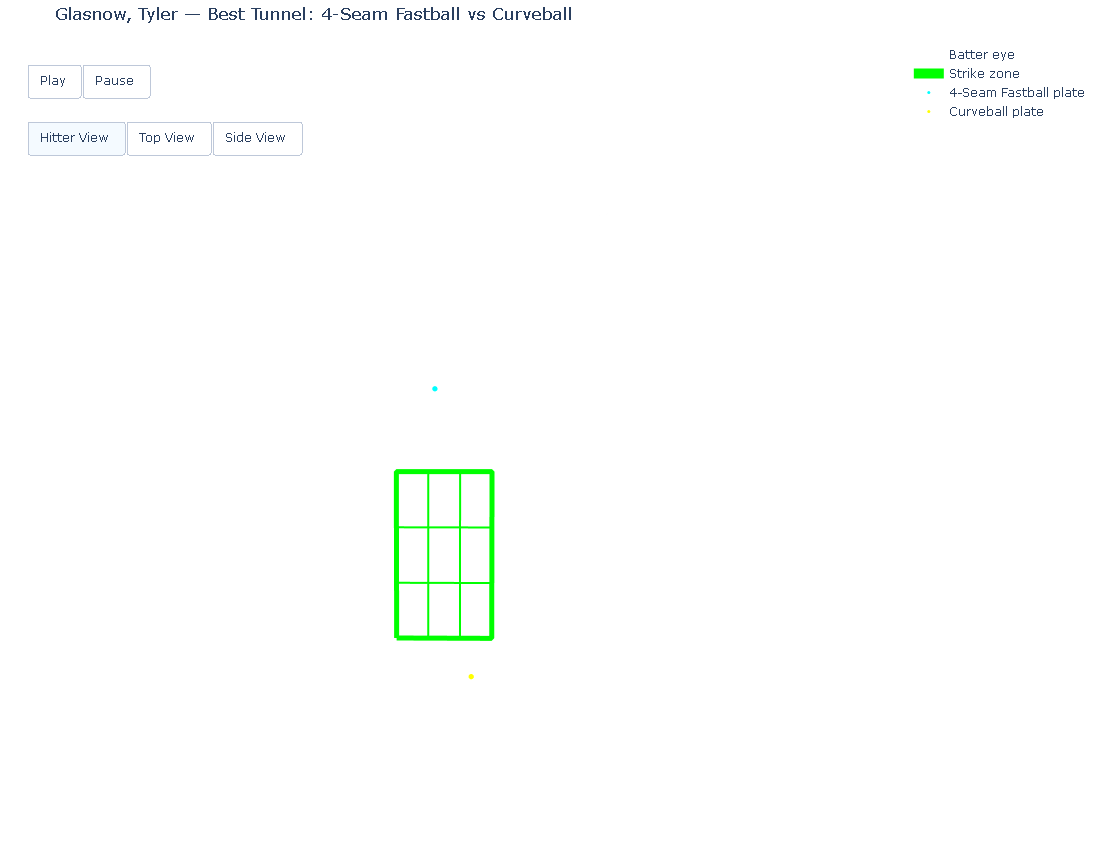

In [46]:
show_tunneled_pair_animated(
    df_2023,
    pitcher_name="Glasnow, Tyler",
    pitch1="FF",
    pitch2="CU",
    pair_mode="best",
    batter_side="L",
    angle_scale=1.0,
    n_points=60,
    camera_preset="hitter"
)